## Sunpy installation and library loading

In [ ]:
!pip install sunpy[net]
!pip install mpl-animators

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.9 MB/s eta 0:00:00


In [ ]:
import astropy.units as u
from astropy.coordinates import EarthLocation, SkyCoord
from astropy.time import Time
from sunpy.coordinates import frames
from sunpy.net import Fido, attrs as a
from sunpy.timeseries import TimeSeries
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd

The following packages are not installed:
['cdflib>=1.3.2']
To install sunpy with these dependencies use `pip install sunpy[timeseries]` or `pip install sunpy[all]` for all extras. 
If you installed sunpy via conda, please report this to the community channel: https://matrix.to/#/#sunpy:openastronomy.org [sunpy.util.sysinfo]
The following packages are not installed:
['cdflib>=1.3.2']
To install sunpy with these dependencies use `pip install sunpy[timeseries]` or `pip install sunpy[all]` for all extras. 
If you installed sunpy via conda, please report this to the community channel: https://matrix.to/#/#sunpy:openastronomy.org


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
### !!!! Please adjust accordingly
workdir = '/content/drive/MyDrive/[2025] [Project] November 2025 events/'

Mounted at /content/drive


## Convert asymptotic directions to HEE system

In [ ]:
def convert_asymptotics(earth_lon, earth_lat, timestamp):

  t = Time(timestamp)

  earth_loc = EarthLocation(lat=earth_lat*u.deg, lon=earth_lon*u.deg, height=1e12*u.km)
  hc_frame = frames.HeliocentricEarthEcliptic(obstime=t)
  earth_hc = earth_loc.get_itrs(obstime=t).transform_to(hc_frame)
  return earth_hc.lon.value, earth_hc.lat.value

In [ ]:
timestamp = '2025-11-11T09:30:00'

lons = np.array([-84.39, -71.72, -118.09, -105.82, 79.86, 103.85, 20.39, 28.97, 41.22, 13.19])
lats = np.array([33.75, 42.54, 34.29, 32.78, 6.90, 1.30, 44.86, 41.01, 39.77, 55.71])
rcs = np.array([3.778, 2.402, 4.866, 4.346, 17.694, 17.402, 4.978, 6.334, np.nan, 2.016])

labels=np.array(['Atlanta, GA', 'Leominster, MA', 'Mount Wilson, CA', 'Apache Point Observatory, NM', \
                 'Colombo, Sri Lanka', 'Singapore, Singapore', 'Belgrade, Serbia', 'Istanbul, Turkey', \
                 'Erzurum, Turkey', 'Lund, Sweden'])

a10_lat = np.array([-23.7, -10.6, -33.1, -30.6, np.nan, np.nan, -16.8, -9.1, -2.6, 5.1])
a10_lon = np.array([-6.4, -15.8, -38.6, -25.5, np.nan, np.nan, 103.7, 141.1, 165.1, 56.1])

a20_lat = np.array([2.4, 14.6, -6.5, -4.7, -1.5, 0.4, 6.2, 0.5, -1.6, 24.7])
a20_lon = np.array([-32.6, -24.0, -71.4, -57.3, -138.1, -117.4, 73.4, 87.5, 101.9, 55.2])

a10_lat_conv = np.zeros_like(a10_lat)
a10_lon_conv = np.zeros_like(a10_lon)
a20_lat_conv = np.zeros_like(a20_lat)
a20_lon_conv = np.zeros_like(a20_lon)

for i in range (0, len(a10_lat)):
  a10_lon_conv[i], a10_lat_conv[i] = convert_asymptotics(a10_lon[i], a10_lat[i], timestamp)
  a20_lon_conv[i], a20_lat_conv[i] = convert_asymptotics(a20_lon[i], a20_lat[i], timestamp)

/usr/local/lib/python3.12/dist-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in gd2gce
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/usr/local/lib/python3.12/dist-packages/erfa/core.py:4620: RuntimeWarning: invalid value encountered in ld
  p1 = ufunc.ld(bm, p, q, e, em, dlim)
/usr/local/lib/python3.12/dist-packages/erfa/core.py:19004: RuntimeWarning: invalid value encountered in anp
  c_retval = ufunc.anp(a)


## Note of the solar wind

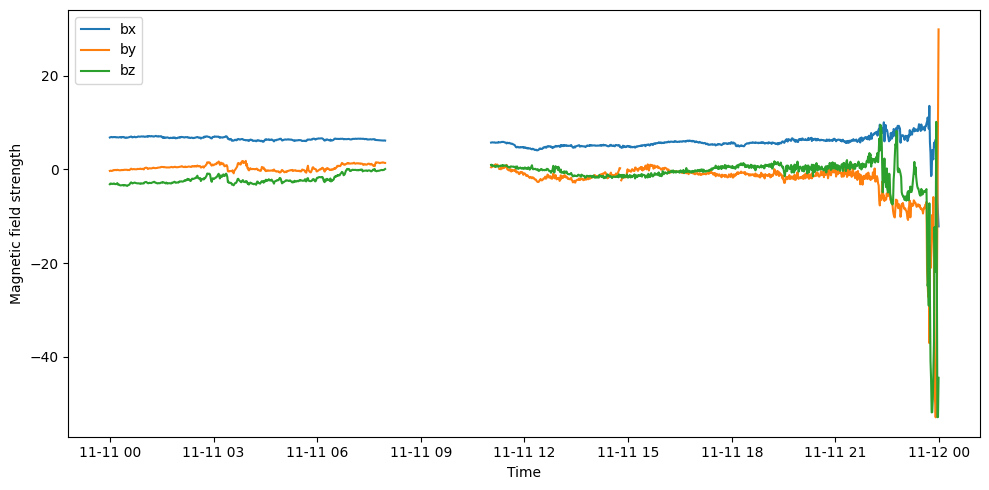

In [ ]:
sw_data = workdir + 'oe_m1m_dscovr_s20251111000000_e20251111235959_p20251112020818_pub.nc'
ds_sw = xr.open_dataset(sw_data)

bx_gse = np.array(ds_sw.bx_gse.data)
by_gse = np.array(ds_sw.by_gse.data)
bz_gse = np.array(ds_sw.bz_gse.data)
sw_time = np.array(ds_sw.time.data)

im, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(sw_time, bx_gse, label='bx')
ax.plot(sw_time, by_gse, label='by')
ax.plot(sw_time, bz_gse, label='bz')
ax.set(xlabel='Time', ylabel='Magnetic field strength')
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
print(np.nanmean(bx_gse[660:720]))
print(np.nanmean(by_gse[660:720]))
print(np.nanmean(bz_gse[660:720]))

5.4085965
0.03999999
0.5850876


While the DSCOVR magnetic data and OMIN data exists,

## Visualization of asymptotic directions and impact

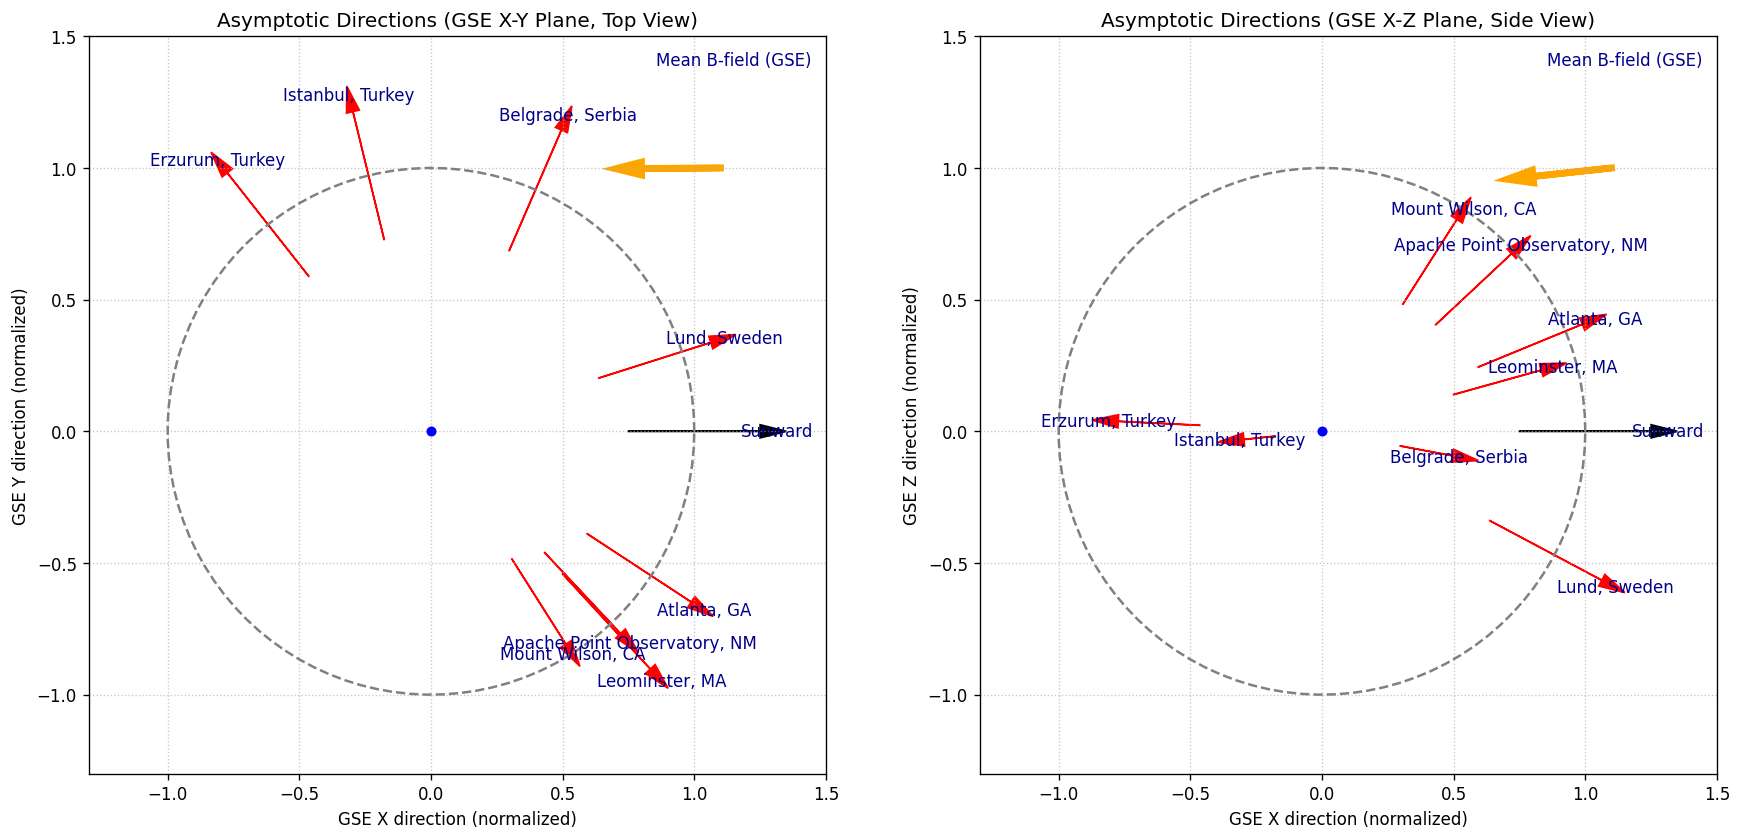

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def return_circle(radius):
  theta = np.linspace(0, 2*np.pi, 100)
  x = radius*np.cos(theta)
  y = radius*np.sin(theta)
  return x, y

def plot_directional_line(lon_deg, lat_deg, linelabel, arrow_color, ax, plane='xy', text_color='darkblue'):
  lon_rad = np.deg2rad(lon_deg)
  lat_rad = np.deg2rad(lat_deg)
  x_comp = np.cos(lat_rad) * np.cos(lon_rad)
  y_comp = np.cos(lat_rad) * np.sin(lon_rad)
  z_comp = np.sin(lat_rad)

  scale_start = 0.75
  scale_end = 1.25

  if plane == 'xy':
    # Project onto x-y plane
    plot_x = x_comp
    plot_y = y_comp
    ax.arrow(scale_start * plot_x, scale_start * plot_y,
             (scale_end - scale_start) * plot_x, (scale_end - scale_start) * plot_y,
             head_width=0.05, head_length=0.1, fc=arrow_color, ec=arrow_color, linewidth=1)
    ax.text(scale_end * plot_x * 1.05, scale_end * plot_y * 1.05, linelabel, color=text_color, fontsize=10, ha='center', va='center')

  elif plane == 'xz':
    # Project onto x-z plane
    plot_x = x_comp
    plot_z = z_comp
    ax.arrow(scale_start * plot_x, scale_start * plot_z,
             (scale_end - scale_start) * plot_x, (scale_end - scale_start) * plot_z,
             head_width=0.05, head_length=0.1, fc=arrow_color, ec=arrow_color, linewidth=1)
    ax.text(scale_end * plot_x * 1.05, scale_end * plot_z * 1.05, linelabel, color=text_color, fontsize=10, ha='center', va='center')

im, ax = plt.subplots(1, 2, figsize=(15,7), dpi=120)

xcircle, ycircle = return_circle(1)

a10_lat_gse_plot = np.zeros_like(a10_lat_conv)
a10_lon_gse_plot = np.zeros_like(a10_lon_conv)

for i in range(0, len(a10_lat_conv)):
  if not np.isnan(a10_lon_conv[i]) and not np.isnan(a10_lat_conv[i]):
    lon_rad_hee = np.deg2rad(a10_lon_conv[i])
    lat_rad_hee = np.deg2rad(a10_lat_conv[i])

    x_hee = np.cos(lat_rad_hee) * np.cos(lon_rad_hee)
    y_hee = np.cos(lat_rad_hee) * np.sin(lon_rad_hee)
    z_hee = np.sin(lat_rad_hee)

    x_gse_plot_cart = -x_hee
    y_gse_plot_cart = -y_hee
    z_gse_plot_cart = -z_hee

    z_gse_plot_cart = np.clip(z_gse_plot_cart, -1.0, 1.0)
    a10_lat_gse_plot[i] = np.degrees(np.arcsin(z_gse_plot_cart))
    a10_lon_gse_plot[i] = np.degrees(np.arctan2(y_gse_plot_cart, x_gse_plot_cart))
  else:
    a10_lat_gse_plot[i] = np.nan
    a10_lon_gse_plot[i] = np.nan

ax[0].plot(xcircle, ycircle, color='gray', linestyle='--', label='Unit Sphere Projection')
ax[0].plot(0, 0, 'o', color='blue', markersize=5, label='Earth Position')

plot_directional_line(0.0, 0.0, 'Sunward', 'black', ax[0], plane='xy', text_color='darkblue')

for i in range(0, len(lons)):
  if not np.isnan(a10_lon_gse_plot[i]) and not np.isnan(a10_lat_gse_plot[i]):
    plot_directional_line(a10_lon_gse_plot[i], a10_lat_gse_plot[i], labels[i], 'red', ax[0], plane='xy', text_color='darkblue')

mean_bx_gse = np.nanmean(bx_gse[660:720])
mean_by_gse = np.nanmean(by_gse[660:720])

arrow_start_x_xy = 1.1
arrow_start_y_xy = 1.0
arrow_length_scale = 0.3

magnitude_xy = np.sqrt(mean_bx_gse**2 + mean_by_gse**2)
if magnitude_xy > 0:
    norm_bx_xy = mean_bx_gse / magnitude_xy
    norm_by_xy = mean_by_gse / magnitude_xy
else:
    norm_bx_xy, norm_by_xy = 0, 0

ax[0].arrow(arrow_start_x_xy, arrow_start_y_xy,
            -norm_bx_xy * arrow_length_scale, -norm_by_xy * arrow_length_scale,
            head_width=0.05, head_length=0.1, fc='orange', ec='orange', linewidth=4)

ax[0].text(0.98, 0.98, 'Mean B-field (GSE)', color='darkblue', fontsize=10, ha='right', va='top', transform=ax[0].transAxes)

ax[0].set_xlim([-1.3, 1.5])
ax[0].set_ylim([-1.3, 1.5])
ax[0].set_aspect('equal', adjustable='box')
ax[0].grid(True, linestyle=':', alpha=0.7)
ax[0].set_xlabel('GSE X direction (normalized)', fontsize=10)
ax[0].set_ylabel('GSE Y direction (normalized)', fontsize=10)
ax[0].set_title('Asymptotic Directions (GSE X-Y Plane, Top View)', fontsize=12)

ax[1].plot(xcircle, ycircle, color='gray', linestyle='--', label='Unit Sphere Projection')
ax[1].plot(0, 0, 'o', color='blue', markersize=5, label='Earth Position')

plot_directional_line(0.0, 0.0, 'Sunward', 'black', ax[1], plane='xz', text_color='darkblue')

for i in range(0, len(lons)):
  if not np.isnan(a10_lon_gse_plot[i]) and not np.isnan(a10_lat_gse_plot[i]):
    plot_directional_line(a10_lon_gse_plot[i], a10_lat_gse_plot[i], labels[i], 'red', ax[1], plane='xz', text_color='darkblue')

mean_bx_gse = np.nanmean(bx_gse[660:720])
mean_bz_gse = np.nanmean(bz_gse[660:720])

arrow_start_x_xz = 1.1
arrow_start_y_xz = 1.0

magnitude_xz = np.sqrt(mean_bx_gse**2 + mean_bz_gse**2)
if magnitude_xz > 0:
    norm_bx_xz = mean_bx_gse / magnitude_xz
    norm_bz_xz = mean_bz_gse / magnitude_xz
else:
    norm_bx_xz, norm_bz_xz = 0, 0

ax[1].arrow(arrow_start_x_xz, arrow_start_y_xz,
            -norm_bx_xz * arrow_length_scale, -norm_bz_xz * arrow_length_scale,
            head_width=0.05, head_length=0.1, fc='orange', ec='orange', linewidth=4)

ax[1].text(0.98, 0.98, 'Mean B-field (GSE)', color='darkblue', fontsize=10, ha='right', va='top', transform=ax[1].transAxes)

ax[1].set_xlim([-1.3, 1.5])
ax[1].set_ylim([-1.3, 1.5])
ax[1].set_aspect('equal', adjustable='box')
ax[1].grid(True, linestyle=':', alpha=0.7)
ax[1].set_xlabel('GSE X direction (normalized)', fontsize=10)
ax[1].set_ylabel('GSE Z direction (normalized)', fontsize=10)
ax[1].set_title('Asymptotic Directions (GSE X-Z Plane, Side View)', fontsize=12)

plt.tight_layout()
plt.savefig('asymptotic_directions.svg', format='svg')
plt.show()

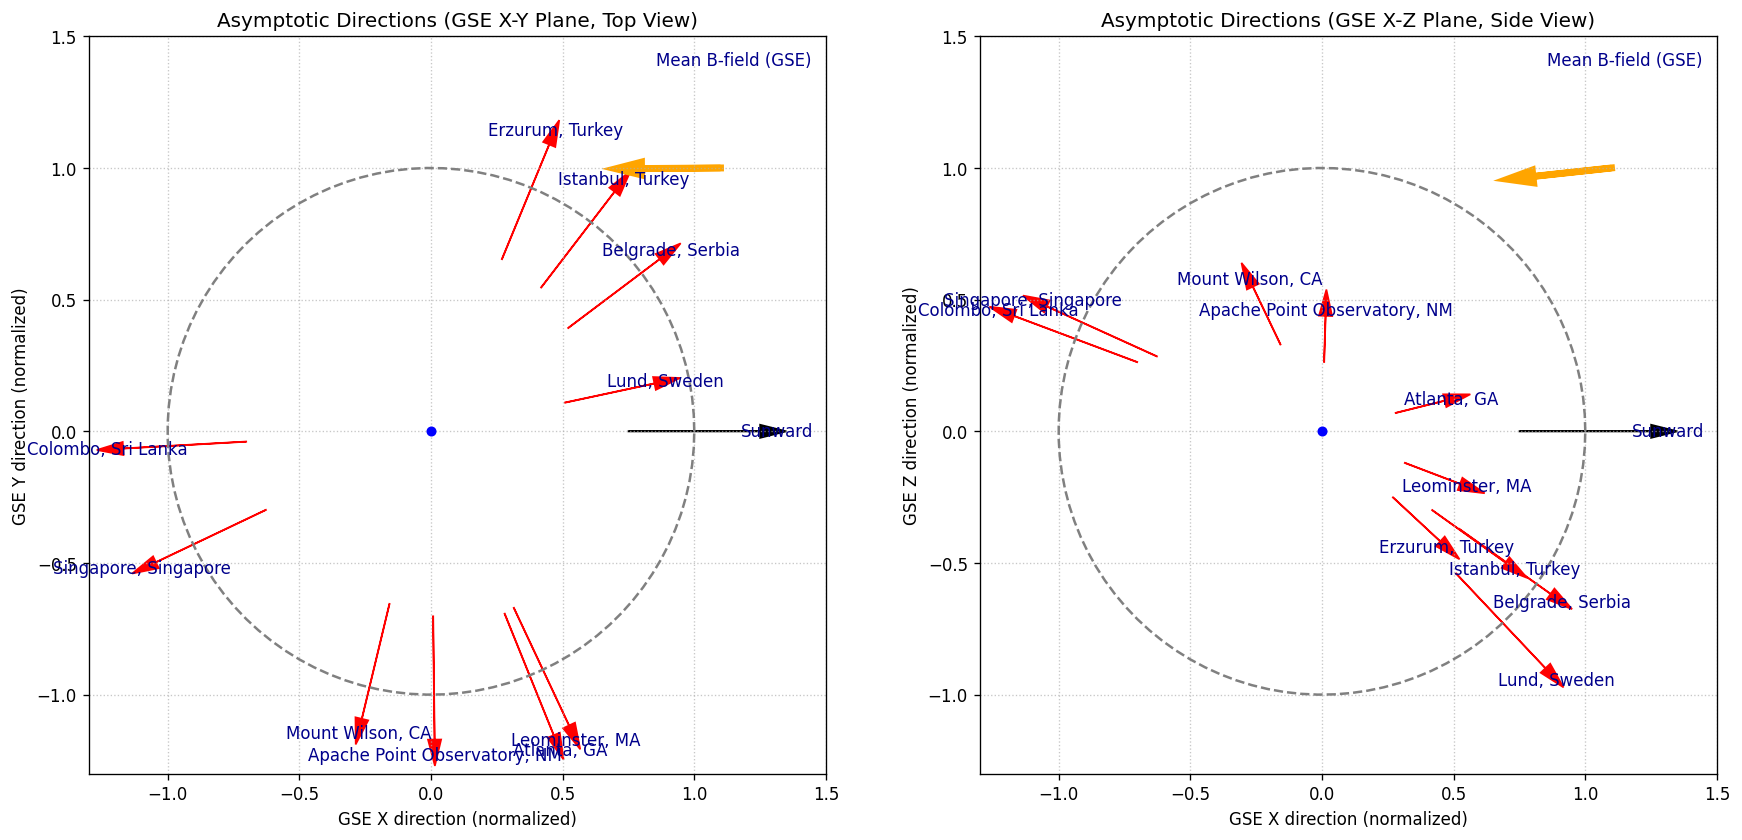

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def return_circle(radius):
  theta = np.linspace(0, 2*np.pi, 100)
  x = radius*np.cos(theta)
  y = radius*np.sin(theta)
  return x, y

def plot_directional_line(lon_deg, lat_deg, linelabel, arrow_color, ax, plane='xy', text_color='darkblue'):
  lon_rad = np.deg2rad(lon_deg)
  lat_rad = np.deg2rad(lat_deg)

  x_comp = np.cos(lat_rad) * np.cos(lon_rad)
  y_comp = np.cos(lat_rad) * np.sin(lon_rad)
  z_comp = np.sin(lat_rad)

  scale_start = 0.75
  scale_end = 1.25

  if plane == 'xy':
    plot_x = x_comp
    plot_y = y_comp
    ax.arrow(scale_start * plot_x, scale_start * plot_y,
             (scale_end - scale_start) * plot_x, (scale_end - scale_start) * plot_y,
             head_width=0.05, head_length=0.1, fc=arrow_color, ec=arrow_color, linewidth=1)
    ax.text(scale_end * plot_x * 1.05, scale_end * plot_y * 1.05, linelabel, color=text_color, fontsize=10, ha='center', va='center')

  elif plane == 'xz':
    plot_x = x_comp
    plot_z = z_comp
    ax.arrow(scale_start * plot_x, scale_start * plot_z,
             (scale_end - scale_start) * plot_x, (scale_end - scale_start) * plot_z,
             head_width=0.05, head_length=0.1, fc=arrow_color, ec=arrow_color, linewidth=1)
    ax.text(scale_end * plot_x * 1.05, scale_end * plot_z * 1.05, linelabel, color=text_color, fontsize=10, ha='center', va='center')

im, ax = plt.subplots(1, 2, figsize=(15,7), dpi=120)

xcircle, ycircle = return_circle(1)

a20_lat_gse_plot = np.zeros_like(a20_lat_conv)
a20_lon_gse_plot = np.zeros_like(a20_lon_conv)

for i in range(0, len(a20_lat_conv)):
  if not np.isnan(a20_lon_conv[i]) and not np.isnan(a20_lat_conv[i]):
    lon_rad_hee = np.deg2rad(a20_lon_conv[i])
    lat_rad_hee = np.deg2rad(a20_lat_conv[i])

    x_hee = np.cos(lat_rad_hee) * np.cos(lon_rad_hee)
    y_hee = np.cos(lat_rad_hee) * np.sin(lon_rad_hee)
    z_hee = np.sin(lat_rad_hee)

    x_gse_plot_cart = -x_hee
    y_gse_plot_cart = -y_hee
    z_gse_plot_cart = -z_hee


    z_gse_plot_cart = np.clip(z_gse_plot_cart, -1.0, 1.0)
    a20_lat_gse_plot[i] = np.degrees(np.arcsin(z_gse_plot_cart))
    a20_lon_gse_plot[i] = np.degrees(np.arctan2(y_gse_plot_cart, x_gse_plot_cart))
  else:
    a20_lat_gse_plot[i] = np.nan
    a20_lon_gse_plot[i] = np.nan

ax[0].plot(xcircle, ycircle, color='gray', linestyle='--', label='Unit Sphere Projection')
ax[0].plot(0, 0, 'o', color='blue', markersize=5, label='Earth Position')

plot_directional_line(0.0, 0.0, 'Sunward', 'black', ax[0], plane='xy', text_color='darkblue')

for i in range(0, len(lons)):
  if not np.isnan(a20_lon_gse_plot[i]) and not np.isnan(a20_lat_gse_plot[i]):
    plot_directional_line(a20_lon_gse_plot[i], a20_lat_gse_plot[i], labels[i], 'red', ax[0], plane='xy', text_color='darkblue')


mean_bx_gse = np.nanmean(bx_gse[660:720])
mean_by_gse = np.nanmean(by_gse[660:720])

arrow_start_x_xy = 1.1
arrow_start_y_xy = 1.0
arrow_length_scale = 0.3

magnitude_xy = np.sqrt(mean_bx_gse**2 + mean_by_gse**2)
if magnitude_xy > 0:
    norm_bx_xy = mean_bx_gse / magnitude_xy
    norm_by_xy = mean_by_gse / magnitude_xy
else:
    norm_bx_xy, norm_by_xy = 0, 0

ax[0].arrow(arrow_start_x_xy, arrow_start_y_xy,
            -norm_bx_xy * arrow_length_scale, -norm_by_xy * arrow_length_scale,
            head_width=0.05, head_length=0.1, fc='orange', ec='orange', linewidth=4)

ax[0].text(0.98, 0.98, 'Mean B-field (GSE)', color='darkblue', fontsize=10, ha='right', va='top', transform=ax[0].transAxes)

ax[0].set_xlim([-1.3, 1.5])
ax[0].set_ylim([-1.3, 1.5])
ax[0].set_aspect('equal', adjustable='box')
ax[0].grid(True, linestyle=':', alpha=0.7)
ax[0].set_xlabel('GSE X direction (normalized)', fontsize=10)
ax[0].set_ylabel('GSE Y direction (normalized)', fontsize=10)
ax[0].set_title('Asymptotic Directions (GSE X-Y Plane, Top View)', fontsize=12)

ax[1].plot(xcircle, ycircle, color='gray', linestyle='--', label='Unit Sphere Projection')
ax[1].plot(0, 0, 'o', color='blue', markersize=5, label='Earth Position')

plot_directional_line(0.0, 0.0, 'Sunward', 'black', ax[1], plane='xz', text_color='darkblue')

for i in range(0, len(lons)):
  if not np.isnan(a20_lon_gse_plot[i]) and not np.isnan(a20_lat_gse_plot[i]):
    plot_directional_line(a20_lon_gse_plot[i], a20_lat_gse_plot[i], labels[i], 'red', ax[1], plane='xz', text_color='darkblue')

mean_bx_gse = np.nanmean(bx_gse[660:720])
mean_bz_gse = np.nanmean(bz_gse[660:720])

arrow_start_x_xz = 1.1
arrow_start_y_xz = 1.0

magnitude_xz = np.sqrt(mean_bx_gse**2 + mean_bz_gse**2)
if magnitude_xz > 0:
    norm_bx_xz = mean_bx_gse / magnitude_xz
    norm_bz_xz = mean_bz_gse / magnitude_xz
else:
    norm_bx_xz, norm_bz_xz = 0, 0

ax[1].arrow(arrow_start_x_xz, arrow_start_y_xz,
            -norm_bx_xz * arrow_length_scale, -norm_bz_xz * arrow_length_scale,
            head_width=0.05, head_length=0.1, fc='orange', ec='orange', linewidth=4)

ax[1].text(0.98, 0.98, 'Mean B-field (GSE)', color='darkblue', fontsize=10, ha='right', va='top', transform=ax[1].transAxes)

ax[1].set_xlim([-1.3, 1.5])
ax[1].set_ylim([-1.3, 1.5])
ax[1].set_aspect('equal', adjustable='box')
ax[1].grid(True, linestyle=':', alpha=0.7)
ax[1].set_xlabel('GSE X direction (normalized)', fontsize=10)
ax[1].set_ylabel('GSE Z direction (normalized)', fontsize=10)
ax[1].set_title('Asymptotic Directions (GSE X-Z Plane, Side View)', fontsize=12)


plt.tight_layout()
plt.savefig('asymptotic_directions_20.svg', format='svg')
plt.show()

# Visualizing the GLE and GOES proton fluxes

In [ ]:
muonfile = workdir + 'pressure_corrected_data/' + 'APO_press_corr.csv'
data = pd.read_csv(muonfile)
data_date = np.array(data['date'])
data_pc = np.array(data['Icorr_12_pres_pct'])

In [ ]:
goesfile = workdir + 'goes19sgps_nov2025.nc'

ds_goes = xr.open_dataset(goesfile)

In [ ]:
ds_goes['DiffProtonEffectiveEnergy']

<xarray.DataArray 'DiffProtonEffectiveEnergy' (time: 24480, sensor_units: 2,
                                               diff_channels: 13)> Size: 3MB
[636480 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 196kB 2025-11-01 ... 2025-11-17T23:59:00
Dimensions without coordinates: sensor_units, diff_channels
Attributes:
    long_name:  Effective energies (geometric means of lower and upper energi...
    units:      keV
    valid_min:  0.0

In [ ]:
goes_time = np.array(ds_goes['time'])
print(goes_time.shape)
print(goes_time)
flux_observed = np.array(ds_goes['AvgDiffProtonFluxObserved'])
flux_observed.shape
energy_eff = np.array(ds_goes['DiffProtonEffectiveEnergy'])
print(energy_eff.shape, energy_eff[0,0,:])

goes_323e = flux_observed[:,0,-1]
goes_323w = flux_observed[:,1,-1]

(24480,)
['2025-11-01T00:00:00.000000000' '2025-11-01T00:01:00.000000000'
 '2025-11-01T00:02:00.000000000' ... '2025-11-17T23:57:00.000000000'
 '2025-11-17T23:58:00.000000000' '2025-11-17T23:59:00.000000000']
(24480, 2, 13) [  1377.3888   2090.4546   2777.661    4693.8257   8014.986   16457.91
  30194.04    55081.758   91422.65   109046.59   127075.414  189548.94
 322691.8   ]


In [ ]:
pressure_corrected_folder = workdir + 'pressure_corrected_data/'

filenames_pc = ['APO_press_corr.csv', 'CHARA_press_corr.csv', 'Erzurum_press_corr.csv', 'Istanbul_press_corr.csv', 'Lund_press_corr.csv', \
                'OneParkPlace_press_corr.csv', 'rm415SA_press_corr.csv', 'Shinshu_press_corr.csv', 'SkyviewMS_press_corr.csv']

labels_pc = ['Apache Point Observatory, NM', 'Mount Wilson, CA', 'Erzurum, Turkey', 'Istanbul, Turkey', 'Lund, Sweden', \
             'Atlanta (detector 1), GA', 'Atlanta (detector 2), GA', 'Shinshu, Japan', 'Leominster, MA']

# reading muon data
def muon_filereader(muonfile):
  data = pd.read_csv(muonfile)
  data_date = np.array(pd.to_datetime(data['date']))
  date_start = pd.to_datetime('2025-11-09 00:00:00').tz_localize('UTC')
  date_end = pd.to_datetime('2025-11-15 00:00:00').tz_localize('UTC')
  indexes = np.where(((data_date >= date_start) & (data_date <= date_end)))
  data_date = data_date[indexes]
  data_pc = np.array(data['Icorr_12_pres_pct'])
  data_pc = data_pc[indexes]
  return data_date, data_pc

# loading GOES data
goesfile = workdir + 'goes19sgps_nov2025.nc'
ds_goes = xr.open_dataset(goesfile)
goes_time = np.array(ds_goes['time'])
flux_observed = np.array(ds_goes['AvgDiffProtonFluxObserved'])
goes_323e = flux_observed[:,0,-1]
goes_323w = flux_observed[:,1,-1]

goes_time_5min = goes_time[3::5]
goes_323e_5min = np.zeros([17*24*12], dtype=float)
goes_323w_5min = np.zeros([17*24*12], dtype=float)
for i in range (0, 17*24*12, 1):
  goes_323e_5min[i] = np.nanmean(goes_323e[i*5:i*5+5])
  goes_323w_5min[i] = np.nanmean(goes_323w[i*5:i*5+5])


date_start = pd.to_datetime('2025-11-09 00:00:00')
date_end = pd.to_datetime('2025-11-15 00:00:00')
indexes = np.where(((goes_time_5min >= date_start) & (goes_time_5min <= date_end)))
goes_time_5min = goes_time_5min[indexes]
goes_323e_5min = goes_323e_5min[indexes]
goes_323w_5min = goes_323w_5min[indexes]

In [ ]:
nm_data = pd.read_csv(
    workdir + 'NeutronMonitor.csv',
    skiprows=1,
    names=['nm_datetime', 'MXCO', 'OULU', 'SOPO'],
    delimiter=';',
    na_values=['null']
)
nm_data['nm_datetime'] = pd.to_datetime(nm_data['nm_datetime'])

nm_data['OULU'] = pd.to_numeric(nm_data['OULU'])
nm_data['SOPO'] = pd.to_numeric(nm_data['SOPO'])

nm_time_1h = np.array(nm_data['nm_datetime'])
nm_oulu = np.array(nm_data['OULU'])

In [ ]:
x_flares = [\
pd.to_datetime('2025-11-09  07:01:00'), \
pd.to_datetime('2025-11-10  08:55:00'), \
pd.to_datetime('2025-11-11  09:49:00'), \
pd.to_datetime('2025-11-14  07:44:00'), \
]

fast_CMEs_750 = [\
pd.to_datetime('2025-11-09  21:12:00'), \
pd.to_datetime('2025-11-10  09:36:00'), \
pd.to_datetime('2025-11-11  10:23:00'), \
pd.to_datetime('2025-11-11  14:45:00'), \
pd.to_datetime('2025-11-13  03:24:00'), \
pd.to_datetime('2025-11-14  01:25:00'), \
pd.to_datetime('2025-11-14  08:00:00'), \
]

ICMEs = [\
pd.to_datetime('2025-11-09  18:05:00'), \
pd.to_datetime('2025-11-11  22:11:00'), \
pd.to_datetime('2025-11-12  18:52:00'), \
]

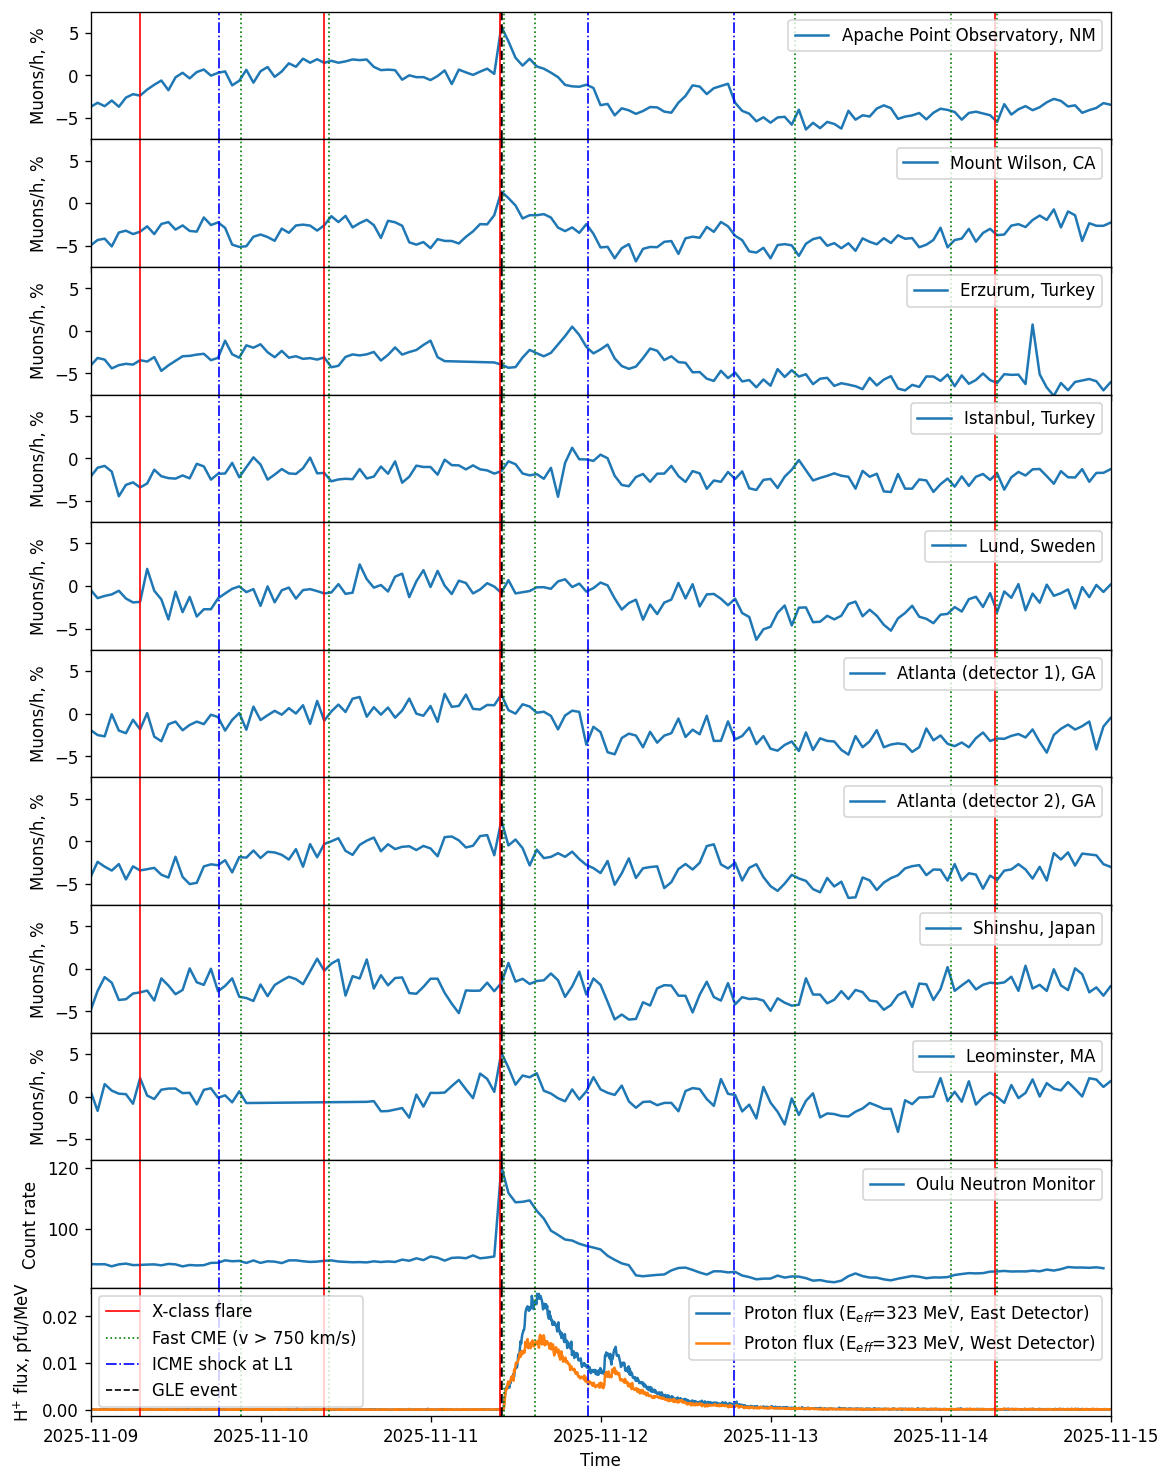

In [ ]:
from matplotlib.lines import Line2D

im, ax = plt.subplots(11, 1, figsize=(10,13), dpi=120, sharex=True)

for i in range (0, 9, 1):
  data_date, data_pc = muon_filereader(pressure_corrected_folder + filenames_pc[i])
  ax[i].plot(data_date, data_pc, label=labels_pc[i])
  ax[i].set(ylabel='Muons/h, %', xlim=[date_start,date_end], ylim=[-7.5,7.5])
  ax[i].legend(loc=1)
  ax[i].tick_params(labelbottom=False)
  ax[i].axvline(pd.to_datetime('2025-11-11 10:00:00'), color='k', linestyle='--')
  for x_flare_time in x_flares:
    ax[i].axvline(x_flare_time, color='red', linestyle='-', lw=1, label='X-flare' if x_flare_time == x_flares[0] else '')
  for cme_time in fast_CMEs_750:
    ax[i].axvline(cme_time, color='green', linestyle=':', lw=1, label='CME' if cme_time == fast_CMEs_750[0] else '')
  for icme_time in ICMEs:
    ax[i].axvline(icme_time, color='blue', linestyle='-.', lw=1, label='ICME shock' if icme_time == ICMEs[0] else '')

ax[9].plot(nm_time_1h, nm_oulu, label='Oulu Neutron Monitor')
ax[9].set(ylabel='Count rate', xlim=[date_start,date_end])
ax[9].legend(loc=1)
ax[9].tick_params(labelbottom=False)
ax[9].axvline(pd.to_datetime('2025-11-11 10:00:00'), color='k', linestyle='--')
for x_flare_time in x_flares:
  ax[9].axvline(x_flare_time, color='red', linestyle='-', lw=1, label='X-flare' if x_flare_time == x_flares[0] else '')
for cme_time in fast_CMEs_750:
  ax[9].axvline(cme_time, color='green', linestyle=':', lw=1, label='CME' if cme_time == fast_CMEs_750[0] else '')
for icme_time in ICMEs:
  ax[9].axvline(icme_time, color='blue', linestyle='-.', lw=1, label='ICME shock' if icme_time == ICMEs[0] else '')

ax[10].plot(goes_time_5min, goes_323e_5min*1e3, label=r'Proton flux (E$_{eff}$=323 MeV, East Detector)')
ax[10].plot(goes_time_5min, goes_323w_5min*1e3, label=r'Proton flux (E$_{eff}$=323 MeV, West Detector)')
ax[10].set(xlabel='Time', ylabel=r'H$^{+}$ flux, pfu/MeV', xlim=[date_start,date_end])
leg1 = ax[10].legend(loc=1)
ax[10].axvline(pd.to_datetime('2025-11-11 10:00:00'), color='k', linestyle='--', label='GLE event')
for x_flare_time in x_flares:
  ax[10].axvline(x_flare_time, color='red', linestyle='-', lw=1, label='X-flare' if x_flare_time == x_flares[0] else '')
for cme_time in fast_CMEs_750:
  ax[10].axvline(cme_time, color='green', linestyle=':', lw=1, label='CME' if cme_time == fast_CMEs_750[0] else '')
for icme_time in ICMEs:
  ax[10].axvline(icme_time, color='blue', linestyle='-.', lw=1, label='ICME shock' if icme_time == ICMEs[0] else '')
custom_lines = [
    Line2D([0], [0], color='red', lw=1, linestyle='-'),
    Line2D([0], [0], color='green', lw=1, linestyle=':'),
    Line2D([0], [0], color='blue', lw=1, linestyle='-.'),
    Line2D([0], [0], color='black', lw=1, linestyle='--')
]
leg2 = ax[10].legend(custom_lines, ['X-class flare', r'Fast CME (v > 750 km/s)', 'ICME shock at L1', 'GLE event'], loc=2)
ax[10].add_artist(leg1)

im.subplots_adjust(hspace=0, wspace=0, left=0.1, right=0.95, top=0.95, bottom=0.05)
plt.savefig('muon_flux_comparison.png')
plt.show()

In [ ]:
# Full list

# x-class flares:
#2025-11-09  07:01 - X1.7
#2025-11-10  08:55 - X1.2
#2025-11-11  09:49 - X5.1
#2025-11-14  07:44 - X4.0

# CMEs
#2025-11-09  07:24 - 734.0
#2025-11-09  13:48 - 610.0
#2025-11-09  21:12 - 975.0
#2025-11-10  09:36 - 1298.0
#2025-11-10  13:08 - 630.0
#2025-11-11  10:23 - 1856.0
#2025-11-11  14:45 - 880.0
#2025-11-13  03:24 - 936.0
#2025-11-13  18:38 - 602.0
#2025-11-14  01:25 - 1081.0
#2025-11-14  08:00 - 1534.0
#2025-11-14  19:45 - 615.0

# ICME shocks
#2025-11-09  18:05
#2025-11-11  22:11
#2025-11-12  18:52

# Working with 1-minute cadence data (for GLE visualization)

In [ ]:
muonfile = workdir + 'one_minute_data/' + 'APO_raw.csv'
data = pd.read_csv(muonfile)
data_date = np.array(data['datetime'])
data_pc = np.array(data['counts12'])

In [ ]:
goesfile = workdir + 'goes19sgps_nov2025.nc'

ds_goes = xr.open_dataset(goesfile)

In [ ]:
goes_time = np.array(ds_goes['time'])
print(goes_time.shape)
print(goes_time)
flux_observed = np.array(ds_goes['AvgDiffProtonFluxObserved'])
flux_observed.shape
energy_eff = np.array(ds_goes['DiffProtonEffectiveEnergy'])
print(energy_eff.shape, energy_eff[0,0,:])

goes_323e = flux_observed[:,0,-1]
goes_323w = flux_observed[:,1,-1]

(24480,)
['2025-11-01T00:00:00.000000000' '2025-11-01T00:01:00.000000000'
 '2025-11-01T00:02:00.000000000' ... '2025-11-17T23:57:00.000000000'
 '2025-11-17T23:58:00.000000000' '2025-11-17T23:59:00.000000000']
(24480, 2, 13) [  1377.3888   2090.4546   2777.661    4693.8257   8014.986   16457.91
  30194.04    55081.758   91422.65   109046.59   127075.414  189548.94
 322691.8   ]


In [ ]:
pressure_corrected_folder = workdir + 'one_minute_data/'

filenames_pc = ['APO_raw.csv', 'California_raw.csv', 'Erzurum_raw.csv', 'Istanbul_raw.csv', 'Lund_raw.csv', \
                'Atlanta_1PP.csv', 'Atlanta_rm415_raw.csv', 'Shinshu_raw.csv', 'Massachussetts_raw.csv']

labels_pc = ['Apache Point Observatory, NM', 'Mount Wilson, CA', 'Erzurum, Turkey', 'Istanbul, Turkey', 'Lund, Sweden', \
             'Atlanta (detector 1), GA', 'Atlanta (detector 2), GA', 'Shinshu, Japan', 'Leominster, MA']

# reading muon data
def muon_filereader(muonfile):
  data = pd.read_csv(muonfile)
  data['datetime'] = pd.to_datetime(data['datetime'])
  data = data.set_index('datetime')
  date_start = pd.to_datetime('2025-11-09 00:00:00').tz_localize('UTC')
  date_end = pd.to_datetime('2025-11-15 00:00:00').tz_localize('UTC')
  data = data[(data.index >= date_start) & (data.index <= date_end)]
  data_resampled = data['counts12'].resample('20min', label='left', origin='start_day').mean()
  data_date = np.array(data_resampled.index + pd.Timedelta(minutes=10))
  data_pc = np.array(data_resampled.values)
  mask = ~np.isnan(data_pc)
  data_date = data_date[mask]
  data_pc = data_pc[mask]
  return data_date, data_pc

# loading GOES data
goesfile = workdir + 'goes19sgps_nov2025.nc'
ds_goes = xr.open_dataset(goesfile)
goes_time = np.array(ds_goes['time'])
flux_observed = np.array(ds_goes['AvgDiffProtonFluxObserved'])
goes_323e = flux_observed[:,0,-1]
goes_323w = flux_observed[:,1,-1]

goes_time_5min = goes_time[3::5]
goes_323e_5min = np.zeros([17*24*12], dtype=float)
goes_323w_5min = np.zeros([17*24*12], dtype=float)
for i in range (0, 17*24*12, 1):
  goes_323e_5min[i] = np.nanmean(goes_323e[i*5:i*5+5])
  goes_323w_5min[i] = np.nanmean(goes_323w[i*5:i*5+5])


date_start = pd.to_datetime('2025-11-09 00:00:00')
date_end = pd.to_datetime('2025-11-15 00:00:00')
indexes = np.where(((goes_time_5min >= date_start) & (goes_time_5min <= date_end)))
goes_time_5min = goes_time_5min[indexes]
goes_323e_5min = goes_323e_5min[indexes]
goes_323w_5min = goes_323w_5min[indexes]

In [ ]:
nm_data = pd.read_csv(
    workdir + 'NeutronMonitor_10min.csv',
    skiprows=1,
    names=['nm_datetime', 'MXCO', 'OULU', 'SOPO'],
    delimiter=';',
    na_values=['null']
)
nm_data['nm_datetime'] = pd.to_datetime(nm_data['nm_datetime'])

nm_data['OULU'] = pd.to_numeric(nm_data['OULU'])
nm_data['SOPO'] = pd.to_numeric(nm_data['SOPO'])

nm_time_1h = np.array(nm_data['nm_datetime'])
nm_oulu = np.array(nm_data['OULU'])

In [ ]:
x_flares = [\
pd.to_datetime('2025-11-09  07:01:00'), \
pd.to_datetime('2025-11-10  08:55:00'), \
pd.to_datetime('2025-11-11  09:49:00'), \
pd.to_datetime('2025-11-14  07:44:00'), \
]

fast_CMEs_750 = [\
pd.to_datetime('2025-11-09  21:12:00'), \
pd.to_datetime('2025-11-10  09:36:00'), \
pd.to_datetime('2025-11-11  10:23:00'), \
pd.to_datetime('2025-11-11  14:45:00'), \
pd.to_datetime('2025-11-13  03:24:00'), \
pd.to_datetime('2025-11-14  01:25:00'), \
pd.to_datetime('2025-11-14  08:00:00'), \
]

ICMEs = [\
pd.to_datetime('2025-11-09  18:05:00'), \
pd.to_datetime('2025-11-11  22:11:00'), \
pd.to_datetime('2025-11-12  18:52:00'), \
]

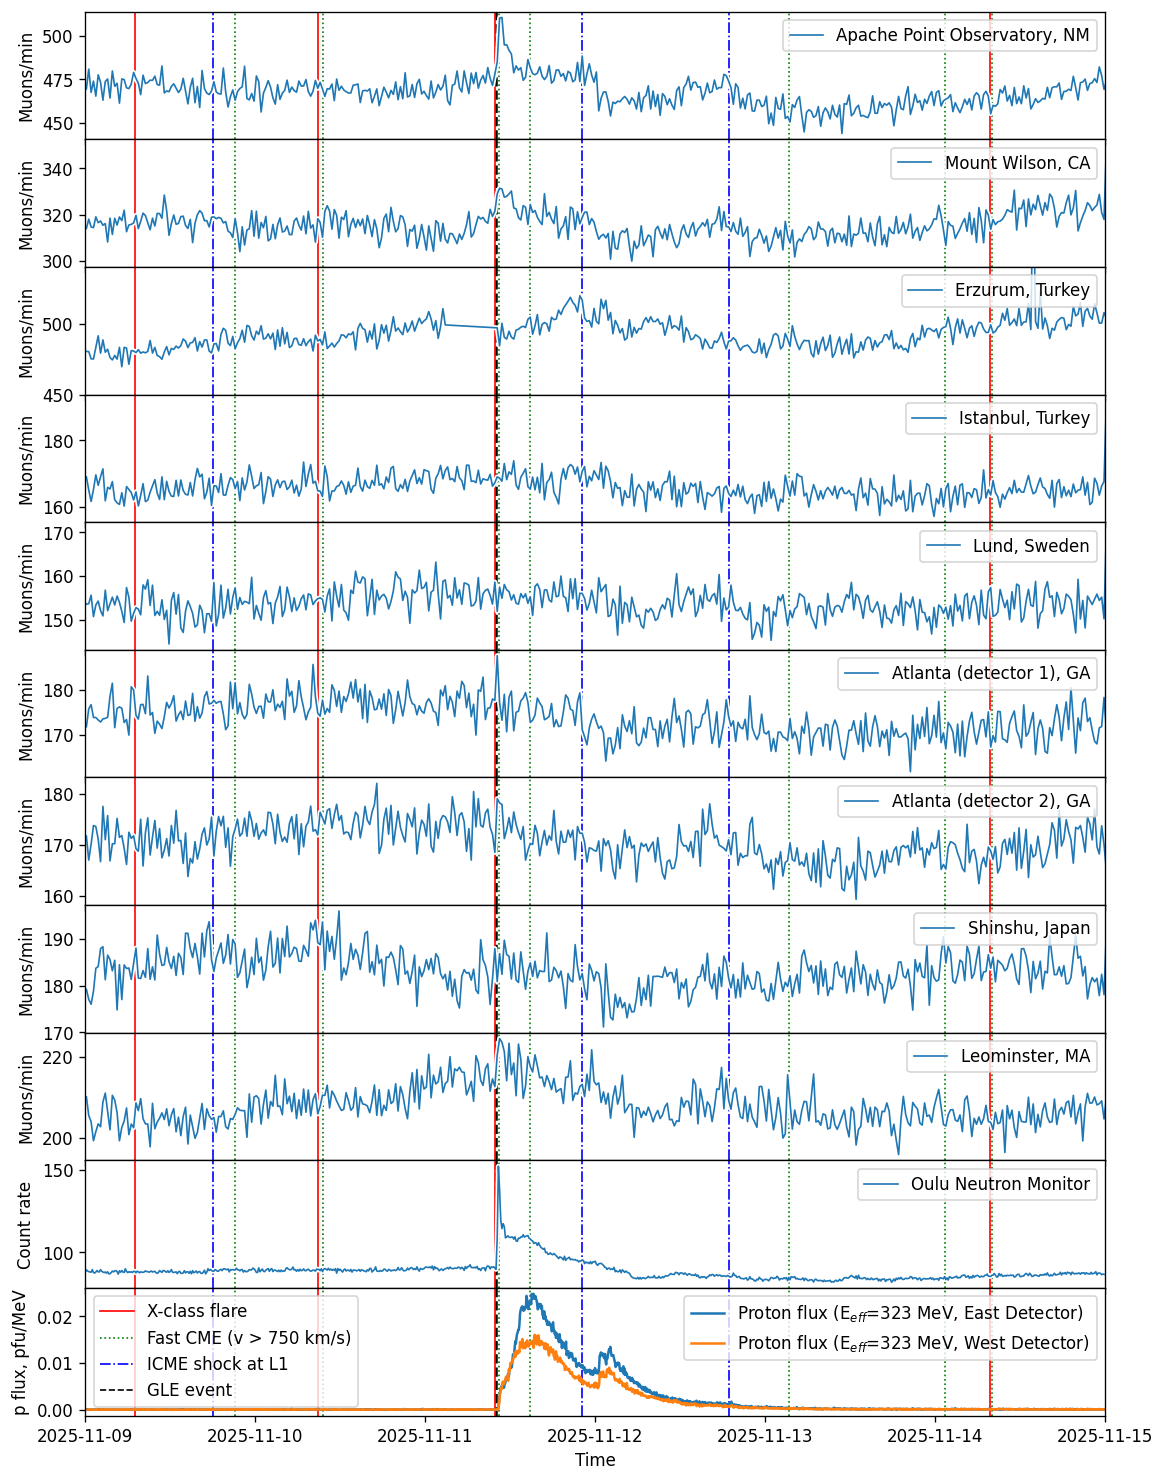

In [ ]:
# reading muon data
def muon_filereader_20(muonfile):
  data = pd.read_csv(muonfile)
  data['datetime'] = pd.to_datetime(data['datetime'])
  data = data.set_index('datetime')
  date_start = pd.to_datetime('2025-11-09 00:00:00').tz_localize('UTC')
  date_end = pd.to_datetime('2025-11-15 00:00:00').tz_localize('UTC')
  data = data[(data.index >= date_start) & (data.index <= date_end)]
  data_resampled = data['counts12'].resample('20min', label='left', origin='start_day').mean()
  data_date = np.array(data_resampled.index + pd.Timedelta(minutes=10))
  data_pc = np.array(data_resampled.values)
  mask = ~np.isnan(data_pc)
  data_date = data_date[mask]
  data_pc = data_pc[mask]
  return data_date, data_pc

from matplotlib.lines import Line2D

im, ax = plt.subplots(11, 1, figsize=(10,13), dpi=120, sharex=True)

for i in range (0, 9, 1):
  data_date, data_pc = muon_filereader_20(pressure_corrected_folder + filenames_pc[i])
  ax[i].axvline(pd.to_datetime('2025-11-11 10:00:00'), color='k', linestyle='--')
  for x_flare_time in x_flares:
    ax[i].axvline(x_flare_time, color='red', linestyle='-', lw=1)
  for cme_time in fast_CMEs_750:
    ax[i].axvline(cme_time, color='green', linestyle=':', lw=1)
  for icme_time in ICMEs:
    ax[i].axvline(icme_time, color='blue', linestyle='-.', lw=1)
  ax[i].plot(data_date, data_pc, color='white', lw=3.0)
  ax[i].plot(data_date, data_pc, label=labels_pc[i], lw=1.0)
  ax[i].set(ylabel='Muons/min', xlim=[date_start,date_end])
  if (i == 2): ax[i].set(ylim=[450,540])
  ax[i].legend(loc=1)
  ax[i].tick_params(labelbottom=False)

ax[9].axvline(pd.to_datetime('2025-11-11 10:00:00'), color='k', linestyle='--')
for x_flare_time in x_flares:
  ax[9].axvline(x_flare_time, color='red', linestyle='-', lw=1)
for cme_time in fast_CMEs_750:
  ax[9].axvline(cme_time, color='green', linestyle=':', lw=1)
for icme_time in ICMEs:
  ax[9].axvline(icme_time, color='blue', linestyle='-.', lw=1)
ax[9].plot(nm_time_1h, nm_oulu, color='white', lw=3.0)
ax[9].plot(nm_time_1h, nm_oulu, label='Oulu Neutron Monitor', lw=1.0)
ax[9].set(ylabel='Count rate', xlim=[date_start,date_end])
ax[9].legend(loc=1)
ax[9].tick_params(labelbottom=False)

ax[10].axvline(pd.to_datetime('2025-11-11 10:00:00'), color='k', linestyle='--')
for x_flare_time in x_flares:
  ax[10].axvline(x_flare_time, color='red', linestyle='-', lw=1)
for cme_time in fast_CMEs_750:
  ax[10].axvline(cme_time, color='green', linestyle=':', lw=1)
for icme_time in ICMEs:
  ax[10].axvline(icme_time, color='blue', linestyle='-.', lw=1)
line_east, = ax[10].plot(goes_time_5min, goes_323e_5min*1e3, label=r'Proton flux (E$_{eff}$=323 MeV, East Detector)')
line_west, = ax[10].plot(goes_time_5min, goes_323w_5min*1e3, label=r'Proton flux (E$_{eff}$=323 MeV, West Detector)')
ax[10].set(xlabel='Time', ylabel=r'p flux, pfu/MeV', xlim=[date_start,date_end])
leg1 = ax[10].legend(handles=[line_east, line_west], loc=1)
custom_lines = [
    Line2D([0], [0], color='red', lw=1, linestyle='-'),
    Line2D([0], [0], color='green', lw=1, linestyle=':'),
    Line2D([0], [0], color='blue', lw=1, linestyle='-.'),
    Line2D([0], [0], color='black', lw=1, linestyle='--')
]
leg2 = ax[10].legend(custom_lines, ['X-class flare', r'Fast CME (v > 750 km/s)', 'ICME shock at L1', 'GLE event'], loc=2)
ax[10].add_artist(leg1)

im.subplots_adjust(hspace=0, wspace=0, left=0.1, right=0.95, top=0.95, bottom=0.05)
plt.savefig('muon_flux_comparison_20min.png')
plt.show()

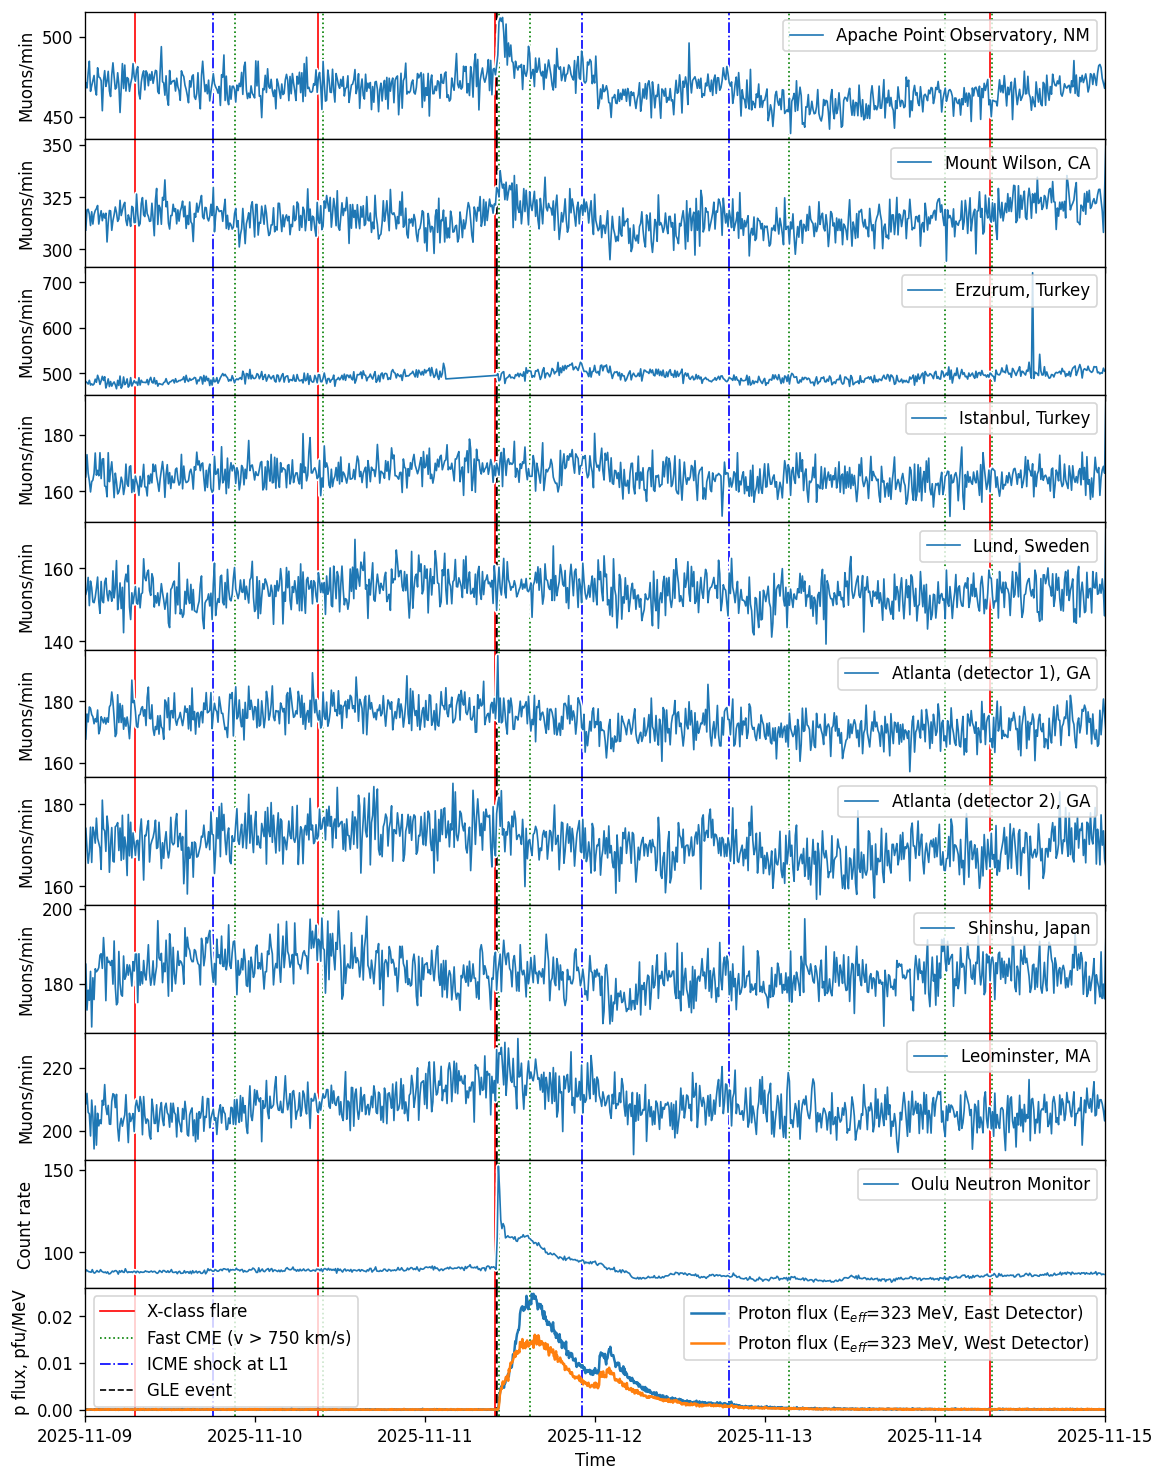

In [ ]:

def muon_filereader_10(muonfile):
  data = pd.read_csv(muonfile)
  data['datetime'] = pd.to_datetime(data['datetime'])
  data = data.set_index('datetime')
  date_start = pd.to_datetime('2025-11-09 00:00:00').tz_localize('UTC')
  date_end = pd.to_datetime('2025-11-15 00:00:00').tz_localize('UTC')
  data = data[(data.index >= date_start) & (data.index <= date_end)]
  data_resampled = data['counts12'].resample('10min', label='left', origin='start_day').mean()
  data_date = np.array(data_resampled.index + pd.Timedelta(minutes=5))
  data_pc = np.array(data_resampled.values)
  mask = ~np.isnan(data_pc)
  data_date = data_date[mask]
  data_pc = data_pc[mask]
  return data_date, data_pc

from matplotlib.lines import Line2D

im, ax = plt.subplots(11, 1, figsize=(10,13), dpi=120, sharex=True)

for i in range (0, 9, 1):
  data_date, data_pc = muon_filereader_10(pressure_corrected_folder + filenames_pc[i])
  ax[i].axvline(pd.to_datetime('2025-11-11 10:00:00'), color='k', linestyle='--')
  for x_flare_time in x_flares:
    ax[i].axvline(x_flare_time, color='red', linestyle='-', lw=1)
  for cme_time in fast_CMEs_750:
    ax[i].axvline(cme_time, color='green', linestyle=':', lw=1)
  for icme_time in ICMEs:
    ax[i].axvline(icme_time, color='blue', linestyle='-.', lw=1)
  ax[i].plot(data_date, data_pc, color='white', lw=3.0)
  ax[i].plot(data_date, data_pc, label=labels_pc[i], lw=1.0)
  ax[i].set(ylabel='Muons/min', xlim=[date_start,date_end])
  ax[i].legend(loc=1)
  ax[i].tick_params(labelbottom=False)

ax[9].axvline(pd.to_datetime('2025-11-11 10:00:00'), color='k', linestyle='--')
for x_flare_time in x_flares:
  ax[9].axvline(x_flare_time, color='red', linestyle='-', lw=1)
for cme_time in fast_CMEs_750:
  ax[9].axvline(cme_time, color='green', linestyle=':', lw=1)
for icme_time in ICMEs:
  ax[9].axvline(icme_time, color='blue', linestyle='-.', lw=1)
ax[9].plot(nm_time_1h, nm_oulu, color='white', lw=3.0)
ax[9].plot(nm_time_1h, nm_oulu, label='Oulu Neutron Monitor', lw=1.0)
ax[9].set(ylabel='Count rate', xlim=[date_start,date_end])
ax[9].legend(loc=1)
ax[9].tick_params(labelbottom=False)

ax[10].axvline(pd.to_datetime('2025-11-11 10:00:00'), color='k', linestyle='--')
for x_flare_time in x_flares:
  ax[10].axvline(x_flare_time, color='red', linestyle='-', lw=1)
for cme_time in fast_CMEs_750:
  ax[10].axvline(cme_time, color='green', linestyle=':', lw=1)
for icme_time in ICMEs:
  ax[10].axvline(icme_time, color='blue', linestyle='-.', lw=1)
line_east, = ax[10].plot(goes_time_5min, goes_323e_5min*1e3, label=r'Proton flux (E$_{eff}$=323 MeV, East Detector)')
line_west, = ax[10].plot(goes_time_5min, goes_323w_5min*1e3, label=r'Proton flux (E$_{eff}$=323 MeV, West Detector)')
ax[10].set(xlabel='Time', ylabel=r'p flux, pfu/MeV', xlim=[date_start,date_end])
leg1 = ax[10].legend(handles=[line_east, line_west], loc=1)
custom_lines = [
    Line2D([0], [0], color='red', lw=1, linestyle='-'),
    Line2D([0], [0], color='green', lw=1, linestyle=':'),
    Line2D([0], [0], color='blue', lw=1, linestyle='-.'),
    Line2D([0], [0], color='black', lw=1, linestyle='--')
]
leg2 = ax[10].legend(custom_lines, ['X-class flare', r'Fast CME (v > 750 km/s)', 'ICME shock at L1', 'GLE event'], loc=2)
ax[10].add_artist(leg1)

im.subplots_adjust(hspace=0, wspace=0, left=0.1, right=0.95, top=0.95, bottom=0.05)
plt.savefig('muon_flux_comparison_10min.png')
plt.show()